# MNIST Handwritten Digit Classification using TensorFlow/Keras

A simple neural network for classifying handwritten digits from the MNIST dataset.

## Objective

Build, train, and evaluate a feed-forward neural network using TensorFlow/Keras to classify handwritten digits from 0 to 9.

### Importing Libraries

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt

### Load MNIST Dataset

In [19]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

### Normalize Images

Pixel values range from 0 to 255 </br>
Neural networks perform better if values are between 0 and 1

In [20]:
train_images = train_images / 255.0
test_images = test_images / 255.0

### Visualize Dataset

In [21]:
print(train_images.shape)
print(test_images.shape)

print(train_labels)

(60000, 28, 28)
(10000, 28, 28)
[5 0 4 ... 5 6 8]


#### Displaying Image

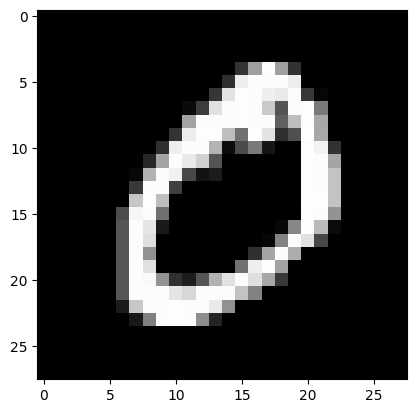

In [22]:
plt.imshow(train_images[1],cmap="gray")
plt.show()

### Build Neural Network

In [23]:
my_model = tf.keras.models.Sequential()

my_model.add(tf.keras.layers.Flatten(input_shape=(28,28)))

my_model.add(tf.keras.layers.Dense(128, activation="relu"))

my_model.add(tf.keras.layers.Dense(10, activation="softmax"))

### Explanation

<b>Flatten Layer</b></br>
Converts 28 × 28 into 784 neurons

<b>Dense Layer</b></br>
Dense(128) Hidden layer with 128 neurons

<b>ReLU</b></br>
activation="relu" Used in hidden layers. </br>
Formula: f(x)=max(0,x)

<b>Output Layer</b></br>
Dense(10) Because MNIST has 10 digits 0 1 2 3 4 5 6 7 8 9

<b>Softmax</b></br>
Converts outputs into probabilities.
Ex, </br>
Digit 0 → 97% </br>
Digit 1 → 1% </br>
Digit 2 → 0.5% </br>
...

### Compile Model

In [24]:
my_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### model summary

In [25]:
my_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Explanation

<b>Adam</b></br>
Optimizer that updates weights.

<b>Loss</b></b>
sparse_categorical_crossentropy </br>
Used for multiclass classification with integer labels.

<b>Accuracy</b></br>
Displays training accuracy.

### Train Model

In [26]:
history = my_model.fit(
    train_images,
    train_labels,
    epochs=3
)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9271 - loss: 0.2538
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9658 - loss: 0.1147
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9760 - loss: 0.0793


### Test Model

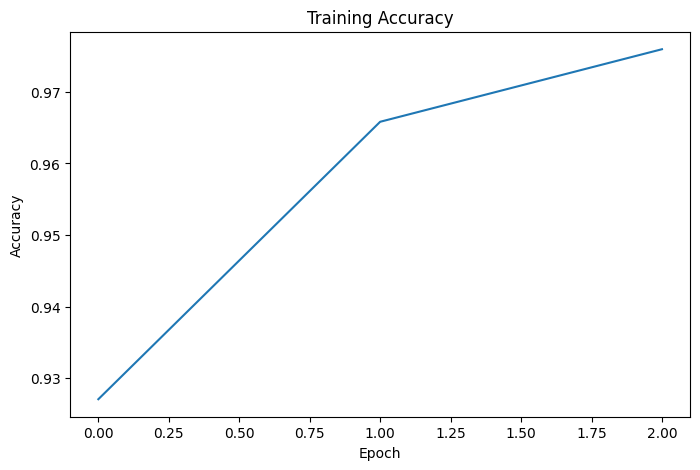

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

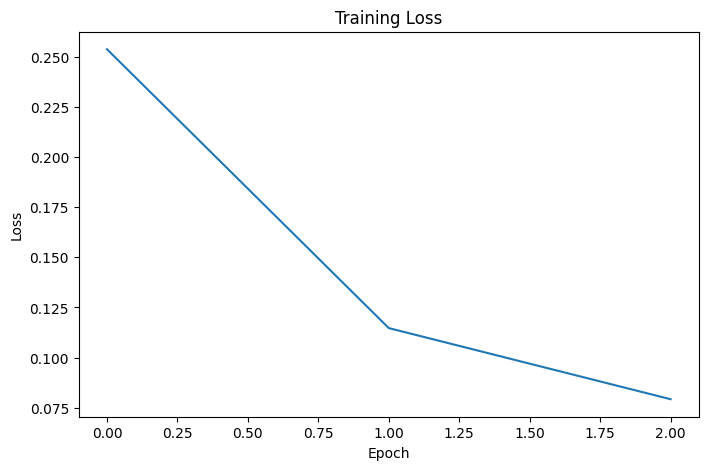

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Add predictions

In [29]:
import numpy as np

predictions = my_model.predict(test_images)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:   ", test_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


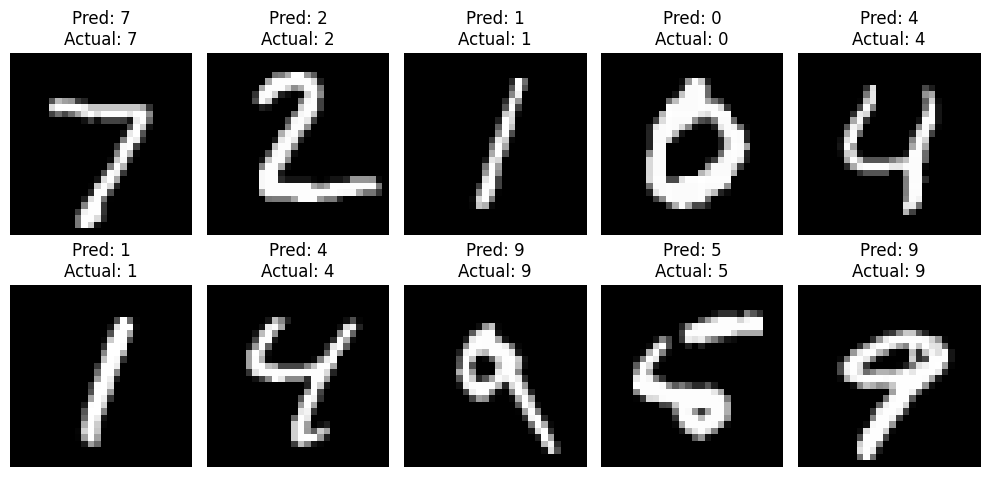

In [30]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i], cmap="gray")
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {test_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### confusion matrix

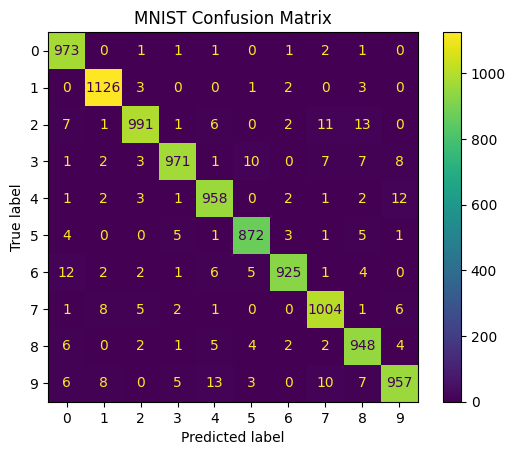

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("MNIST Confusion Matrix")
plt.show()

### save model

In [32]:
my_model.save("mnist_model.keras")